In [1]:
!pip install -U datasets
!pip install -U evaluate jiwer

  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/ec/93/454ada0d1b289a0f4a86ac88dbdeab54921becabac45da3da787d136628f/datasets-2.16.1-py3-none-any.whl.metadata
  Obtaining dependency information for pyarrow-hotfix from https://files.pythonhosted.org/packages/e4/f4/9ec2222f5f5f8ea04f66f184caafd991a39c8782e31f5b0266f101cb68ca/pyarrow_hotfix-0.6-py3-none-any.whl.metadata
  Obtaining dependency information for fsspec[http]<=2023.10.0,>=2023.1.0 from https://files.pythonhosted.org/packages/e8/f6/3eccfb530aac90ad1301c582da228e4763f19e719ac8200752a4841b0b2d/fsspec-2023.10.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.12.2
    Uninstalling fsspec-2023.12.2:
      Successfully uninstalled fsspec-2023.12.2
  Attempting uninstall: datasets

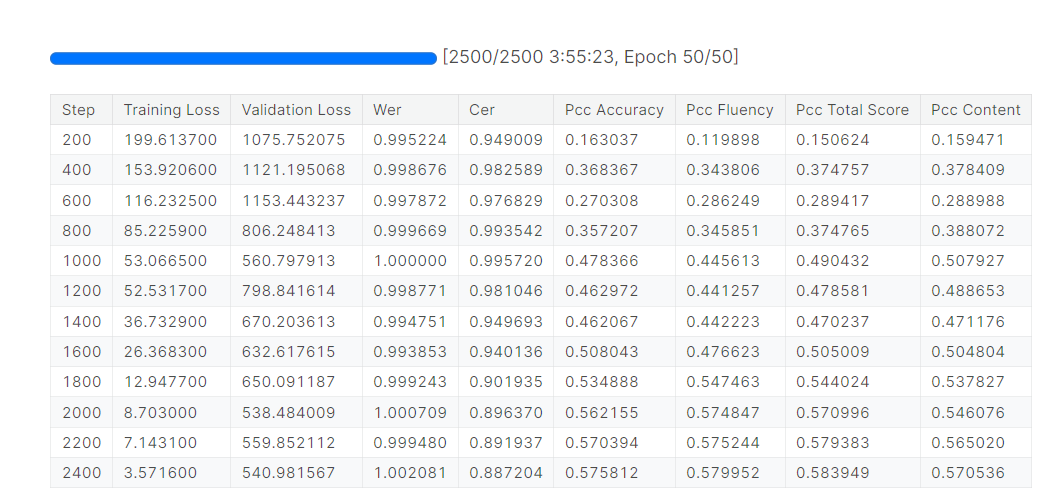

In [2]:
from transformers import Wav2Vec2PreTrainedModel, Wav2Vec2Model
from transformers.modeling_outputs import CausalLMOutput
from typing import Optional, Tuple, Union
import torch
import torch.nn as nn
import math
import warnings

_HIDDEN_STATES_START_POSITION = 2

def _no_grad_trunc_normal_(tensor, mean, std, a, b):
    # Cut & paste from PyTorch official master until it's in a few official releases - RW
    # Method based on https://people.sc.fsu.edu/~jburkardt/presentations/truncated_normal.pdf
    def norm_cdf(x):
        # Computes standard normal cumulative distribution function
        return (1. + math.erf(x / math.sqrt(2.))) / 2.

    if (mean < a - 2 * std) or (mean > b + 2 * std):
        warnings.warn("mean is more than 2 std from [a, b] in nn.init.trunc_normal_. "
                      "The distribution of values may be incorrect.",
                      stacklevel=2)

    with torch.no_grad():
        # Values are generated by using a truncated uniform distribution and
        # then using the inverse CDF for the normal distribution.
        # Get upper and lower cdf values
        l = norm_cdf((a - mean) / std)
        u = norm_cdf((b - mean) / std)

        # Uniformly fill tensor with values from [l, u], then translate to
        # [2l-1, 2u-1].
        tensor.uniform_(2 * l - 1, 2 * u - 1)

        # Use inverse cdf transform for normal distribution to get truncated
        # standard normal
        tensor.erfinv_()

        # Transform to proper mean, std
        tensor.mul_(std * math.sqrt(2.))
        tensor.add_(mean)

        # Clamp to ensure it's in the proper range
        tensor.clamp_(min=a, max=b)
        return tensor

def trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.):
    return _no_grad_trunc_normal_(tensor, mean, std, a, b)


class Wav2Vec2ForWav2Vec2ForCTCAndUttranceRegression(Wav2Vec2PreTrainedModel):
    def __init__(self, config, target_lang: Optional[str] = None):
        super().__init__(config)

        self.wav2vec2 = Wav2Vec2Model(config)
        self.dropout = nn.Dropout(config.final_dropout)

        self.target_lang = target_lang

        if config.vocab_size is None:
            raise ValueError(
                f"You are trying to instantiate {self.__class__} with a configuration that "
                "does not define the vocabulary size of the language model head. Please "
                "instantiate the model as follows: `Wav2Vec2ForCTC.from_pretrained(..., vocab_size=vocab_size)`. "
                "or define `vocab_size` of your model's configuration."
            )
        output_hidden_size = (
            config.output_hidden_size if hasattr(config, "add_adapter") and config.add_adapter else config.hidden_size
        )
        self.lm_head = nn.Linear(output_hidden_size, config.vocab_size)
        
        # utterance level, 1=accuracy, 2=fluency, 3=total score, 4=cotent
        self.cls_token1 = nn.Parameter(torch.zeros(1, 1, config.hidden_size))
        self.mlp_head_utt1 = nn.Sequential(nn.LayerNorm(config.hidden_size), nn.Linear(config.hidden_size, 1))
        
        self.cls_token2 = nn.Parameter(torch.zeros(1, 1, config.hidden_size))
        self.mlp_head_utt2 = nn.Sequential(nn.LayerNorm(config.hidden_size), nn.Linear(config.hidden_size, 1))
        
        self.cls_token3 = nn.Parameter(torch.zeros(1, 1, config.hidden_size))
        self.mlp_head_utt3 = nn.Sequential(nn.LayerNorm(config.hidden_size), nn.Linear(config.hidden_size, 1))
        
        self.cls_token4 = nn.Parameter(torch.zeros(1, 1, config.hidden_size))
        self.mlp_head_utt4 = nn.Sequential(nn.LayerNorm(config.hidden_size), nn.Linear(config.hidden_size, 1))
        self.post_init()
        # initialize the cls tokens
        trunc_normal_(self.cls_token1, std=.092)
        trunc_normal_(self.cls_token2, std=.01)
        trunc_normal_(self.cls_token3, std=.052)
        trunc_normal_(self.cls_token4, std=.02)
        # Initialize weights and apply final processing
        
        
    def tie_weights(self):
        """
        This method overwrites [`~PreTrainedModel.tie_weights`] so that adapter weights can be correctly loaded when
        passing `target_lang=...` to `from_pretrained(...)`.

        This method is **not** supposed to be called by the user and is prone to be changed in the future.
        """

        # Note that `tie_weights` is usually used to tie input and output embedding weights. The method is re-purposed to
        # correctly load adapter layers for Wav2Vec2 so that we do not have to introduce a new API to
        # [`PreTrainedModel`]. While slightly hacky, Wav2Vec2 never has to tie input and output embeddings, so that it is
        # ok to repurpose this function here.
        target_lang = self.target_lang

        if target_lang is not None and getattr(self.config, "adapter_attn_dim", None) is None:
            raise ValueError(f"Cannot pass `target_lang`: {target_lang} if `config.adapter_attn_dim` is not defined.")
        elif target_lang is None and getattr(self.config, "adapter_attn_dim", None) is not None:
            warnings.info("By default `target_lang` is set to 'eng'.")
        elif target_lang is not None:
            self.load_adapter(target_lang, force_load=True)
    
    
    def freeze_feature_extractor(self):
        """
        Calling this function will disable the gradient computation for the feature encoder so that its parameters will
        not be updated during training.
        """
        warnings.warn(
            "The method `freeze_feature_extractor` is deprecated and will be removed in Transformers v5. "
            "Please use the equivalent `freeze_feature_encoder` method instead.",
            FutureWarning,
        )
        self.freeze_feature_encoder()

    def freeze_feature_encoder(self):
        """
        Calling this function will disable the gradient computation for the feature encoder so that its parameter will
        not be updated during training.
        """
        self.wav2vec2.feature_extractor._freeze_parameters()

    def freeze_base_model(self):
        """
        Calling this function will disable the gradient computation for the base model so that its parameters will not
        be updated during training. Only the classification head will be updated.
        """
        for param in self.wav2vec2.parameters():
            param.requires_grad = False

            
    def forward(
        self,
        input_values: Optional[torch.Tensor],
        attention_mask: Optional[torch.Tensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
        labels: Optional[torch.Tensor] = None,
    ) -> Union[Tuple, CausalLMOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size, target_length)`, *optional*):
            Labels for connectionist temporal classification. Note that `target_length` has to be smaller or equal to
            the sequence length of the output logits. Indices are selected in `[-100, 0, ..., config.vocab_size - 1]`.
            All labels set to `-100` are ignored (masked), the loss is only computed for labels in `[0, ...,
            config.vocab_size - 1]`.
        """

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        B, T = input_values.size()
                
        extract_features = self.wav2vec2.feature_extractor(input_values)
        extract_features = extract_features.transpose(1, 2)

        if attention_mask is not None:
            # compute reduced attention_mask corresponding to feature vectors
            attention_mask = self.wav2vec2._get_feature_vector_attention_mask(
                extract_features.shape[1], attention_mask, add_adapter=False
            )

        hidden_states, extract_features = self.wav2vec2.feature_projection(extract_features)
        hidden_states = self.wav2vec2._mask_hidden_states(
            hidden_states, mask_time_indices=None, attention_mask=attention_mask
        )

        cls_token1 = self.cls_token1.expand(B, -1, -1)
        cls_token2 = self.cls_token2.expand(B, -1, -1)
        cls_token3 = self.cls_token3.expand(B, -1, -1)
        cls_token4 = self.cls_token4.expand(B, -1, -1)
        hidden_states = torch.cat((cls_token1, cls_token2, cls_token3, cls_token4, hidden_states), dim=1) #cls_token4
#         hidden_states = torch.cat((cls_token1, cls_token3, hidden_states), dim=1) #cls_token4
        outputs = self.wav2vec2.encoder(
            hidden_states,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        hidden_states = outputs[0]
        hidden_states = self.dropout(hidden_states)

        # the first 4 tokens are utterance-level cls tokens, i.e., accuracy, fluency, total scores, content
        u1 = self.mlp_head_utt1(hidden_states[:, 0])
        u2 = self.mlp_head_utt2(hidden_states[:, 1])
        u3 = self.mlp_head_utt3(hidden_states[:, 2])
        u4 = self.mlp_head_utt4(hidden_states[:, 3])
        
        logits = self.lm_head(hidden_states[:, 4:])

        loss = None
        if labels is not None:
            labels, utt_label = labels['labels'], labels['utt_label'][:, :4]
            if labels.max() >= self.config.vocab_size:
                raise ValueError(f"Label values must be <= vocab_size: {self.config.vocab_size}")

            # retrieve loss input_lengths from attention_mask
            attention_mask = (
                attention_mask if attention_mask is not None else torch.ones_like(input_values, dtype=torch.long)
            )
            input_lengths = self._get_feat_extract_output_lengths(attention_mask.sum(-1)).to(torch.long)

            # assuming that padded tokens are filled with -100
            # when not being attended to
            labels_mask = labels >= 0
            target_lengths = labels_mask.sum(-1)
            flattened_targets = labels.masked_select(labels_mask)

            log_probs = nn.functional.log_softmax(logits, dim=-1, dtype=torch.float32).transpose(0, 1)

            with torch.backends.cudnn.flags(enabled=False):
                # utterance level loss, also mse
                utt_preds = torch.cat((u1, u2, u3, u4), dim=1)
#                 utt_preds = torch.cat((u1, u2), dim=1)

                loss_utt = nn.functional.mse_loss(utt_preds ,utt_label)

                
                loss_ph = nn.functional.ctc_loss(
                    log_probs,
                    flattened_targets,
                    input_lengths,
                    target_lengths,
                    blank=self.config.pad_token_id,
                    reduction=self.config.ctc_loss_reduction,
                    zero_infinity=self.config.ctc_zero_infinity,
                )
                loss = loss_utt + loss_ph

        if not return_dict:
            output = (logits,) + outputs[_HIDDEN_STATES_START_POSITION:]
            return ((loss,) + output) if loss is not None else output
        # utterance level, 1=accuracy, 2=fluency, 3=total score, 4=content, , 'content': u4
        return CausalLMOutput(
            loss=loss, logits={'logits': logits, 'accuracy': u2, 'fluency': u1, 'total score': u3, 'content': u4}, hidden_states=outputs.hidden_states, attentions=outputs.attentions
        )
#         return CausalLMOutput(
#             loss=loss, logits={ 'accuracy': u1, 'total score': u2}, hidden_states=outputs.hidden_states, attentions=outputs.attentions
#         )

In [3]:
from transformers import Wav2Vec2Processor

In [4]:
base_name = '/kaggle/input/mvp-from-client-samples/wav2vec/checkpoint-2400'

In [5]:
processor = Wav2Vec2Processor.from_pretrained(base_name)
model = Wav2Vec2ForWav2Vec2ForCTCAndUttranceRegression.from_pretrained(base_name).cuda()

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [6]:
import string

with open('/kaggle/input/upwork-speech-data/Diapers.txt') as f: 
    text = f.read().lower()
    spoken_text = ''
    for c in text:
        if c not in string.ascii_lowercase + ' ':
            continue
        spoken_text += c
#     spoken_text = spoken_text.replace(' ', ' [silence] ')
    

In [7]:
from datasets import load_dataset, Audio

In [8]:
data = load_dataset('json', data_files='/kaggle/input/upwork-speech-data/Diapers.json')
data = data['train']

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Generating train split: 0 examples [00:00, ? examples/s]

In [9]:
def prepare_data(features):
    features['audio'] = '/kaggle/input/upwork-speech-data/audio/' + features['name']
    features.pop('name')
    features['text'] = spoken_text
    features.pop('url')
#     features['labels'] = [features['fluencyScore'], features['pronunciationScore'], features['totalScore'], features['contentScore']]
#     features.pop('fluencyScore')
#     features.pop('pronunciationScore')
#     features.pop('totalScore')
#     features.pop('contentScore')
    return features

In [10]:
data = data.map(prepare_data)
data = data.cast_column('audio', Audio(16000))

Map:   0%|          | 0/399 [00:00<?, ? examples/s]

In [11]:
def prepare_data(batch):
    batch['length'] = len(batch['audio']["array"])
    batch["input_values"] = processor(batch['audio']["array"], sampling_rate=batch['audio']["sampling_rate"]).input_values[0]
    batch['input_ids']    = processor(text=batch['text']).input_ids
    batch.pop('audio')
    return batch

data = data.map(prepare_data)


Map:   0%|          | 0/399 [00:00<?, ? examples/s]

In [12]:
data

Dataset({
    features: ['fluencyScore', 'contentScore', 'pronunciationScore', 'totalScore', 'text', 'length', 'input_values', 'input_ids'],
    num_rows: 399
})

In [13]:
import torch

In [14]:
def predict(features):
    inputs = torch.tensor(features['input_values']).reshape(1, -1).cuda()
    with torch.no_grad():
        res = model(inputs).logits
    res.pop('logits')
    for key, score in res.items():
        features[f'pred {key}'] = score.cpu().item()
        
    return features

In [15]:
new_data = data.map(predict)

Map:   0%|          | 0/399 [00:00<?, ? examples/s]

In [16]:
new_data

Dataset({
    features: ['fluencyScore', 'contentScore', 'pronunciationScore', 'totalScore', 'text', 'length', 'input_values', 'input_ids', 'pred accuracy', 'pred fluency', 'pred total score', 'pred content'],
    num_rows: 399
})

In [17]:
for row in new_data:
    print('True Pronunciation Score:', row['pronunciationScore'], f"\tpred score: {row['pred accuracy']: 0.0f}")
    print('True Fluency       Score:', row['fluencyScore'],       f"\tpred score: { row['pred fluency']: 0.0f}")
    print('True Content       Score:', row['contentScore'],       f"\tpred score: { row['pred content']: 0.0f}")
    print('True Total         Score:', row['totalScore'],         f"\tpred score: {row['pred total score']: 0.0f}")
    print('+'*50)
    print()

True Pronunciation Score: 10 	pred score:  10
True Fluency       Score: 10 	pred score:  10
True Content       Score: 10 	pred score:  10
True Total         Score: 10 	pred score:  10
++++++++++++++++++++++++++++++++++++++++++++++++++

True Pronunciation Score: 61 	pred score:  62
True Fluency       Score: 63 	pred score:  65
True Content       Score: 65 	pred score:  68
True Total         Score: 62 	pred score:  64
++++++++++++++++++++++++++++++++++++++++++++++++++

True Pronunciation Score: 10 	pred score:  10
True Fluency       Score: 10 	pred score:  10
True Content       Score: 10 	pred score:  11
True Total         Score: 10 	pred score:  10
++++++++++++++++++++++++++++++++++++++++++++++++++

True Pronunciation Score: 10 	pred score:  10
True Fluency       Score: 10 	pred score:  11
True Content       Score: 15 	pred score:  13
True Total         Score: 11 	pred score:  12
++++++++++++++++++++++++++++++++++++++++++++++++++

True Pronunciation Score: 44 	pred score:  44
True Fluen